In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

np.random.seed(10)

In [38]:
a = 1
b = 100

def rosenbrock(params):
    x, y = params
    return (a - x)**2 + b * (y - x**2)**2

def rosenbrock_gradient(params):
    x, y = params
    dx = -2 * (a - x) - 4 * b * x * (y - x**2)
    dy = 2 * b * (y - x**2)
    return np.array([dx, dy], dtype=float)


In [39]:
def ackley(x):
    x = float(np.asarray(x).reshape(-1)[0])

    if abs(x) < 1e-12:
        return 0.0

    return (
        -20 * np.exp(-0.2 * abs(x))
        - np.exp(np.cos(2 * np.pi * x))
        + 20
        + np.e
    )

def ackley_gradient(x):
    x = float(np.asarray(x).reshape(-1)[0])

    if abs(x) < 1e-12:
        return np.array([0.0])

    term1 = 4 * np.exp(-0.2 * abs(x)) * np.sign(x)

    term2 = (
        2 * np.pi
        * np.exp(np.cos(2 * np.pi * x))
        * np.sin(2 * np.pi * x)
    )

    return np.array([term1 + term2])


In [40]:
def get_function_value(func, params):
    if np.size(params) == 1:
        return func(float(np.asarray(params).reshape(-1)[0]))
    return func(params)


In [41]:
def gradient_descent(
    func,
    grad_func,
    initial_params,
    lr,
    max_iter=50000,
    tolerance=1e-8,
    gradient_clip=1000
):
    params = np.array(initial_params, dtype=float)
    history = []
    start_time = time.time()
    status = "Maximum iterations"

    for iteration in range(max_iter):
        value = get_function_value(func, params)

        if not np.isfinite(value):
            status = "Diverged"
            break

        history.append(value)

        gradient = np.array(grad_func(params), dtype=float)

        if not np.all(np.isfinite(gradient)):
            status = "Diverged"
            break

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:
            gradient = gradient * gradient_clip / gradient_norm

        new_params = params - lr * gradient

        if not np.all(np.isfinite(new_params)):
            status = "Diverged"
            break

        if np.linalg.norm(new_params - params) < tolerance:
            params = new_params
            status = "Converged"
            break

        params = new_params

    elapsed_time = time.time() - start_time
    final_value = get_function_value(func, params)

    if not np.isfinite(final_value):
        status = "Diverged"

    return {
        "params": params,
        "value": final_value,
        "history": history,
        "time": elapsed_time,
        "iterations": len(history),
        "status": status
    }


In [42]:
def momentum_gradient_descent(
    func,
    grad_func,
    initial_params,
    lr,
    beta=0.9,
    max_iter=50000,
    tolerance=1e-8,
    gradient_clip=1000
):
    params = np.array(initial_params, dtype=float)
    velocity = np.zeros_like(params)
    history = []
    start_time = time.time()
    status = "Maximum iterations"

    for iteration in range(max_iter):
        value = get_function_value(func, params)

        if not np.isfinite(value):
            status = "Diverged"
            break

        history.append(value)

        gradient = np.array(grad_func(params), dtype=float)

        if not np.all(np.isfinite(gradient)):
            status = "Diverged"
            break

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:
            gradient = gradient * gradient_clip / gradient_norm

        velocity = beta * velocity + gradient
        new_params = params - lr * velocity

        if not np.all(np.isfinite(new_params)):
            status = "Diverged"
            break

        if np.linalg.norm(new_params - params) < tolerance:
            params = new_params
            status = "Converged"
            break

        params = new_params

    elapsed_time = time.time() - start_time
    final_value = get_function_value(func, params)

    if not np.isfinite(final_value):
        status = "Diverged"

    return {
        "params": params,
        "value": final_value,
        "history": history,
        "time": elapsed_time,
        "iterations": len(history),
        "status": status
    }


In [43]:
def adam(
    func,
    grad_func,
    initial_params,
    lr,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    max_iter=50000,
    tolerance=1e-8,
    gradient_clip=1000
):
    params = np.array(initial_params, dtype=float)
    m = np.zeros_like(params)
    v = np.zeros_like(params)
    history = []
    start_time = time.time()
    status = "Maximum iterations"

    for t in range(1, max_iter + 1):
        value = get_function_value(func, params)

        if not np.isfinite(value):
            status = "Diverged"
            break

        history.append(value)

        gradient = np.array(grad_func(params), dtype=float)

        if not np.all(np.isfinite(gradient)):
            status = "Diverged"
            break

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:
            gradient = gradient * gradient_clip / gradient_norm

        m = beta1 * m + (1 - beta1) * gradient
        v = beta2 * v + (1 - beta2) * gradient**2

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        new_params = params - lr * m_hat / (np.sqrt(v_hat) + epsilon)

        if not np.all(np.isfinite(new_params)):
            status = "Diverged"
            break

        if np.linalg.norm(new_params - params) < tolerance:
            params = new_params
            status = "Converged"
            break

        params = new_params

    elapsed_time = time.time() - start_time
    final_value = get_function_value(func, params)

    if not np.isfinite(final_value):
        status = "Diverged"

    return {
        "params": params,
        "value": final_value,
        "history": history,
        "time": elapsed_time,
        "iterations": len(history),
        "status": status
    }


In [44]:
def rmsprop(
    func,
    grad_func,
    initial_params,
    lr,
    beta=0.9,
    epsilon=1e-8,
    max_iter=50000,
    tolerance=1e-8,
    gradient_clip=1000
):
    params = np.array(initial_params, dtype=float)
    squared_gradient = np.zeros_like(params)
    history = []
    start_time = time.time()
    status = "Maximum iterations"

    for iteration in range(max_iter):
        value = get_function_value(func, params)

        if not np.isfinite(value):
            status = "Diverged"
            break

        history.append(value)

        gradient = np.array(grad_func(params), dtype=float)

        if not np.all(np.isfinite(gradient)):
            status = "Diverged"
            break

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:
            gradient = gradient * gradient_clip / gradient_norm

        squared_gradient = (
            beta * squared_gradient
            + (1 - beta) * gradient**2
        )

        new_params = (
            params
            - lr * gradient
            / (np.sqrt(squared_gradient) + epsilon)
        )

        if not np.all(np.isfinite(new_params)):
            status = "Diverged"
            break

        if np.linalg.norm(new_params - params) < tolerance:
            params = new_params
            status = "Converged"
            break

        params = new_params

    elapsed_time = time.time() - start_time
    final_value = get_function_value(func, params)

    if not np.isfinite(final_value):
        status = "Diverged"

    return {
        "params": params,
        "value": final_value,
        "history": history,
        "time": elapsed_time,
        "iterations": len(history),
        "status": status
    }


In [45]:
def adagrad(
    func,
    grad_func,
    initial_params,
    lr,
    epsilon=1e-8,
    max_iter=50000,
    tolerance=1e-8,
    gradient_clip=1000
):
    params = np.array(initial_params, dtype=float)
    accumulated_gradient = np.zeros_like(params)
    history = []
    start_time = time.time()
    status = "Maximum iterations"

    for iteration in range(max_iter):
        value = get_function_value(func, params)

        if not np.isfinite(value):
            status = "Diverged"
            break

        history.append(value)

        gradient = np.array(grad_func(params), dtype=float)

        if not np.all(np.isfinite(gradient)):
            status = "Diverged"
            break

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:
            gradient = gradient * gradient_clip / gradient_norm

        accumulated_gradient += gradient**2

        new_params = (
            params
            - lr * gradient
            / (np.sqrt(accumulated_gradient) + epsilon)
        )

        if not np.all(np.isfinite(new_params)):
            status = "Diverged"
            break

        if np.linalg.norm(new_params - params) < tolerance:
            params = new_params
            status = "Converged"
            break

        params = new_params

    elapsed_time = time.time() - start_time
    final_value = get_function_value(func, params)

    if not np.isfinite(final_value):
        status = "Diverged"

    return {
        "params": params,
        "value": final_value,
        "history": history,
        "time": elapsed_time,
        "iterations": len(history),
        "status": status
    }


In [46]:
optimizers = {
    "Gradient Descent": gradient_descent,
    "Momentum": momentum_gradient_descent,
    "Adam": adam,
    "RMSprop": rmsprop,
    "Adagrad": adagrad
}

learning_rates = [0.01, 0.05, 0.1]

initial_rosenbrock = [0.5, 1]

rosen_results = {}

for lr in learning_rates:
    rosen_results[lr] = {}

    for name, optimizer in optimizers.items():
        print(f"Running {name} with learning rate {lr}")

        result = optimizer(
            rosenbrock,
            rosenbrock_gradient,
            initial_rosenbrock,
            lr
        )

        rosen_results[lr][name] = result


Running Gradient Descent with learning rate 0.01
Running Momentum with learning rate 0.01
Running Adam with learning rate 0.01
Running RMSprop with learning rate 0.01
Running Adagrad with learning rate 0.01
Running Gradient Descent with learning rate 0.05
Running Momentum with learning rate 0.05
Running Adam with learning rate 0.05
Running RMSprop with learning rate 0.05
Running Adagrad with learning rate 0.05
Running Gradient Descent with learning rate 0.1
Running Momentum with learning rate 0.1
Running Adam with learning rate 0.1
Running RMSprop with learning rate 0.1
Running Adagrad with learning rate 0.1


In [47]:
rows = []

for lr in learning_rates:
    for name in optimizers:
        result = rosen_results[lr][name]

        rows.append({
            "Learning Rate": lr,
            "Optimizer": name,
            "Final x": result["params"][0],
            "Final y": result["params"][1],
            "Final f(x,y)": result["value"],
            "Iterations": result["iterations"],
            "Time (seconds)": result["time"],
            "Status": result["status"]
        })

rosen_df = pd.DataFrame(rows)
rosen_df


,Learning Rate,Optimizer,Final x,Final y,"Final f(x,y)",Iterations,Time (seconds),Status
0,0.01,Gradient Descent,-6.387857,10.497436,9.190767e+04,50000,2.671795,Maximum iterations
1,0.01,Momentum,28.103848,14.843196,6.006061e+07,50000,2.486498,Maximum iterations
2,0.01,Adam,0.999999,0.999999,4.407535e-13,6625,0.376658,Converged
3,0.01,RMSprop,0.980149,0.975543,2.245074e-02,50000,2.111165,Maximum iterations
4,0.01,Adagrad,0.863607,0.745268,1.863315e-02,50000,1.894554,Maximum iterations
5,0.05,Gradient Descent,-66.676901,528.506268,1.534531e+09,50000,1.824791,Maximum iterations
6,0.05,Momentum,-59.228748,489.803610,9.109815e+08,50000,2.034977,Maximum iterations
7,0.05,Adam,1.000000,0.999999,2.165522e-13,3050,0.148078,Converged
8,0.05,RMSprop,0.675000,0.515625,4.656250e-01,50000,3.386350,Maximum iterations
9,0.05,Adagrad,0.992162,0.984356,6.151895e-05,50000,2.174506,Maximum iterations


## 9. Rosenbrock Convergence Plots

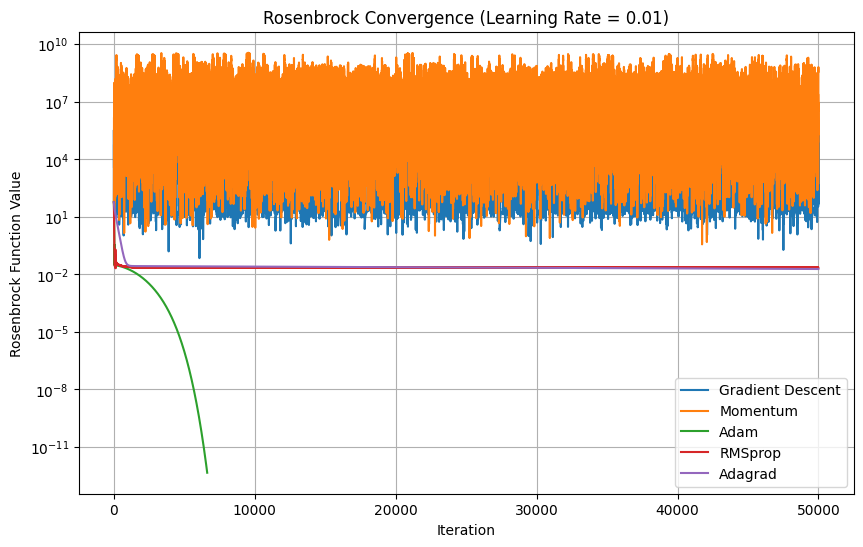

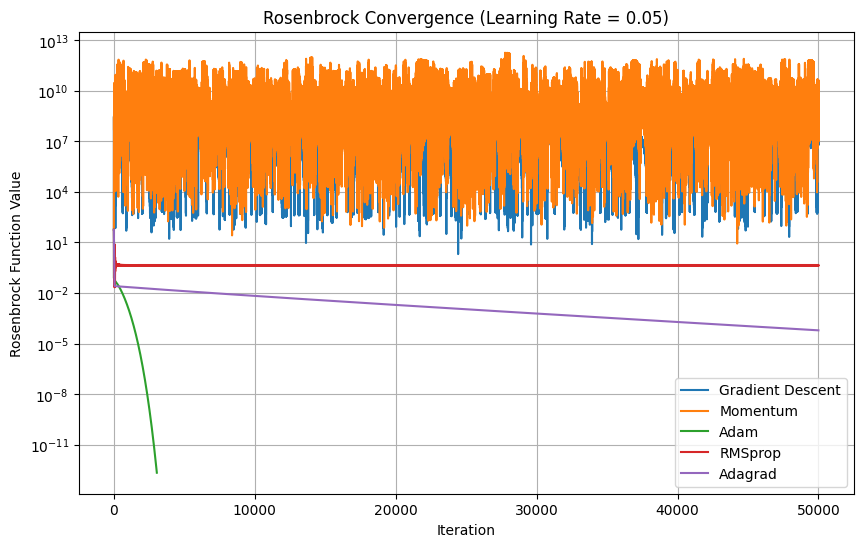

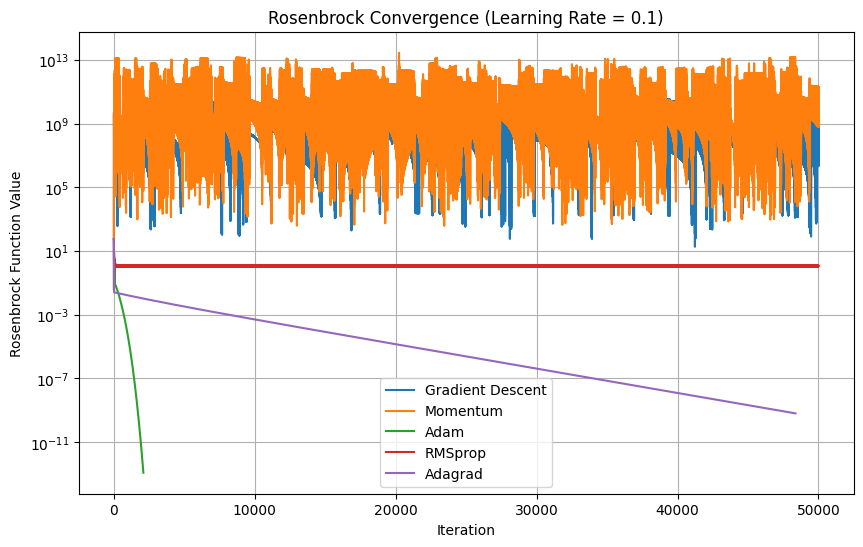

In [48]:
for lr in learning_rates:
    plt.figure(figsize=(10, 6))

    for name in optimizers:
        history = rosen_results[lr][name]["history"]

        if len(history) > 0:
            history = np.maximum(history, 1e-16)
            plt.plot(history, label=name)

    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Rosenbrock Function Value")
    plt.title(f"Rosenbrock Convergence (Learning Rate = {lr})")
    plt.legend()
    plt.grid(True)
    plt.show()


In [61]:
initial_ackley = [4]

ackley_results = {}

for lr in learning_rates:
    ackley_results[lr] = {}

    for name, optimizer in optimizers.items():
        print(f"Running {name} with learning rate {lr}")

        result = optimizer(
            ackley,
            ackley_gradient,
            initial_ackley,
            lr
        )

        ackley_results[lr][name] = result


Running Gradient Descent with learning rate 0.01
Running Momentum with learning rate 0.01
Running Adam with learning rate 0.01
Running RMSprop with learning rate 0.01
Running Adagrad with learning rate 0.01
Running Gradient Descent with learning rate 0.05
Running Momentum with learning rate 0.05
Running Adam with learning rate 0.05
Running RMSprop with learning rate 0.05
Running Adagrad with learning rate 0.05
Running Gradient Descent with learning rate 0.1
Running Momentum with learning rate 0.1
Running Adam with learning rate 0.1
Running RMSprop with learning rate 0.1
Running Adagrad with learning rate 0.1


In [62]:
rows = []

for lr in learning_rates:
    for name in optimizers:
        result = ackley_results[lr][name]

        rows.append({
            "Learning Rate": lr,
            "Optimizer": name,
            "Final x": result["params"][0],
            "Final f(x)": result["value"],
            "Iterations": result["iterations"],
            "Time (seconds)": result["time"],
            "Status": result["status"]
        })

ackley_df = pd.DataFrame(rows)
ackley_df


,Learning Rate,Optimizer,Final x,Final f(x),Iterations,Time (seconds),Status
0,0.01,Gradient Descent,3.983068,10.998262,6,0.000646,Converged
1,0.01,Momentum,3.983065,10.998262,168,0.015630,Converged
2,0.01,Adam,3.983067,10.998262,209,0.023213,Converged
3,0.01,RMSprop,3.988034,10.999557,50000,3.064596,Maximum iterations
4,0.01,Adagrad,3.983068,10.998262,19,0.001915,Converged
5,0.05,Gradient Descent,0.236179,2.550432,50000,2.171394,Maximum iterations
6,0.05,Momentum,73.883861,20.611076,50000,2.353683,Maximum iterations
7,0.05,Adam,3.983068,10.998262,240,0.026523,Converged
8,0.05,RMSprop,4.007193,11.029113,50000,3.910822,Maximum iterations
9,0.05,Adagrad,3.983068,10.998262,17,0.001979,Converged


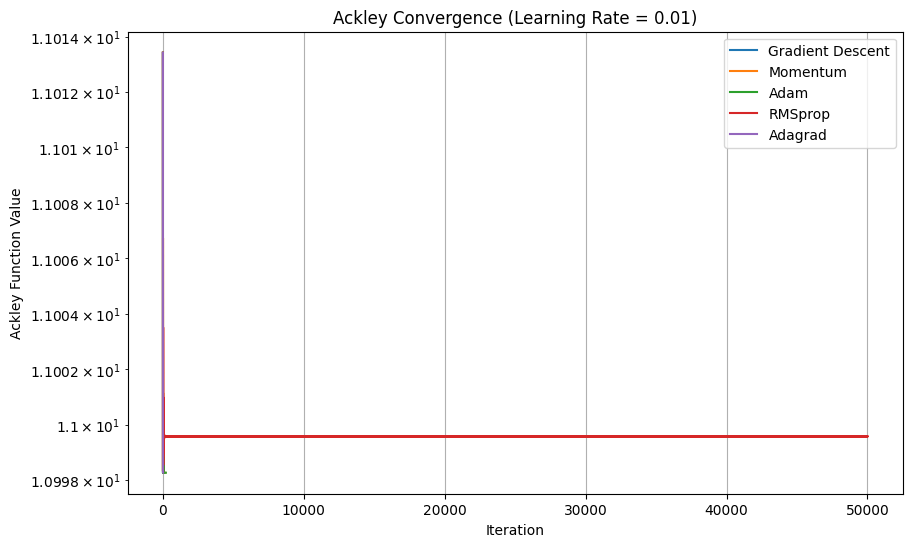

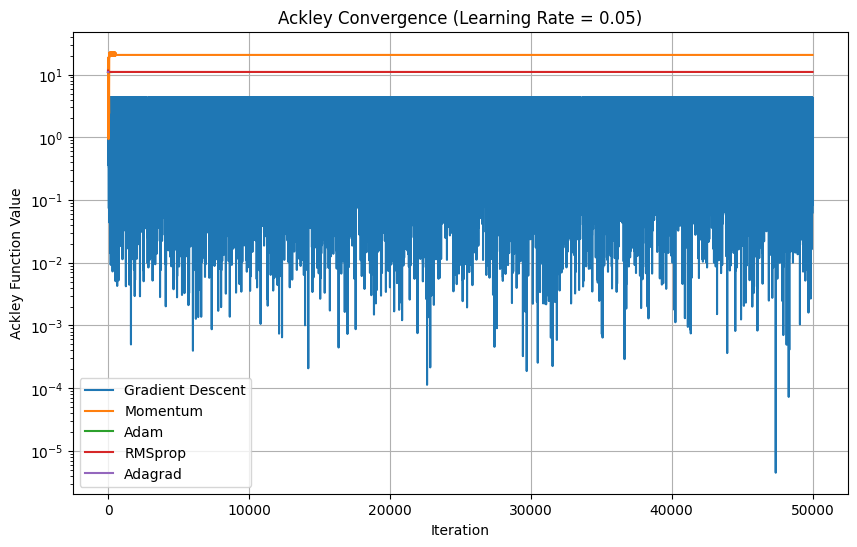

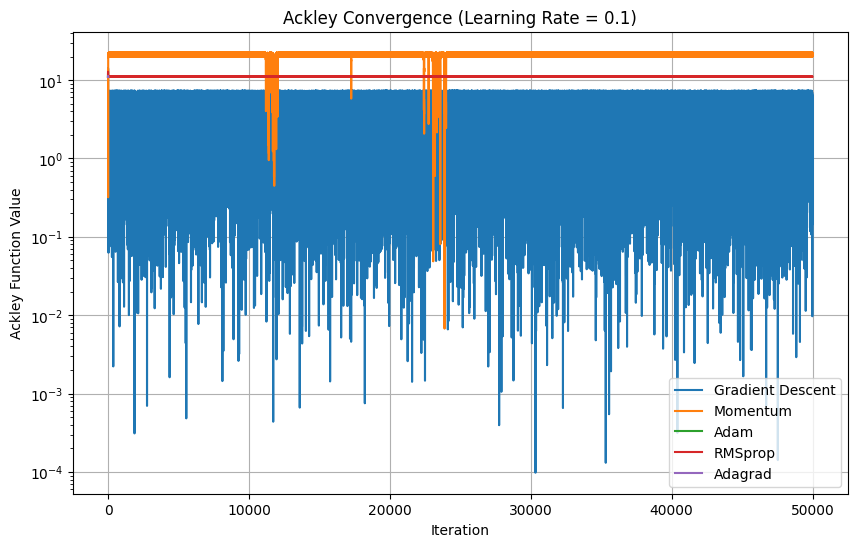

In [63]:
for lr in learning_rates:
    plt.figure(figsize=(10, 6))

    for name in optimizers:
        history = ackley_results[lr][name]["history"]

        if len(history) > 0:
            history = np.maximum(history, 1e-16)
            plt.plot(history, label=name)

    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Ackley Function Value")
    plt.title(f"Ackley Convergence (Learning Rate = {lr})")
    plt.legend()
    plt.grid(True)
    plt.show()
